# Qick view and study signal from UHF/VHF [50-3000] MHz SRSP "Ra"

## Libraries

In [1]:
import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings("ignore")

In [16]:
import os
import gc
import requests
import fnmatch
from bs4 import BeautifulSoup

import numpy as np
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter, NullFormatter

from datetime import date
from datetime import datetime, timezone, timedelta
from astropy.io import fits

In [3]:
gc.enable()

## Functions

In [4]:
def listFD(url, ext=''):
    page = requests.get(url).text
    soup = BeautifulSoup(page, 'html.parser')
    return [url + '/' + node.get('href') for node in soup.find_all('a') if node.get('href').endswith(ext)]

def download(url: str, dest_folder: str):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)  # create folder if it does not exist

    filename = url.split('/')[-1].replace(" ", "_")  # be careful with file names
    file_path = os.path.join(dest_folder, filename)

    r = requests.get(url, stream=True)
    if r.ok:
        print("saving to", os.path.abspath(file_path))
        with open(file_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024 * 8):
                if chunk:
                    f.write(chunk)
                    f.flush()
                    os.fsync(f.fileno())
    else:  # HTTP status code 4XX/5XX
        print("Download failed: status code {}\n{}".format(r.status_code, r.text))

def hhmm_format(t, pos=0):
    hh = (int)(t / 3600.)
    t -= hh*3600.
    mm = (int)(t / 60.)
    ss = (int)(t % 60)
    return '%02d:%02d:%02d' % (hh,mm,ss)

def to_ticks(hhmmstr, hhmmend):
    try:
        hhs, mms = hhmmstr.split(':')
        hhe, mme = hhmmend.split(':')
        startobs = int(hhs) * 3600 + int(mms) * 60 + 3600 * 3
        endobs = int(hhe) * 3600 + int(mme) * 60 + 3600 * 3
    except:
        try:
            hhs, mms, sss = hhmmstr.split(':')
            hhe, mme, sse = hhmmend.split(':')
            startobs = int(hhs) * 3600 + int(mms) * 60 + int(sse) * 60 + 3600 * 3
            endobs = int(hhe) * 3600 + int(mme) * 60 + int(sse) * 60 + 3600 * 3
        except:
            print("Time's format undefined")
        
    
    return (startobs, endobs)

def tics_coff_dt(t_1, t_2):
    if (t_2 - t_1) // 4 == 0:
        coff_dt = (t_2 - t_1) / 4
    else:
        coff_dt = (t_2 - t_1) // 4
    return coff_dt

In [11]:
def plotSpectra(radiodata, freqrange=[0,-1], pol=0, yscalelog=False, 
                 vmin=-21, vmax=-11,
                 dateview = datetime.now(),
                 t1 = "03:00", t2 = "16:00",
                 cmap="rainbow", improve=False, saveplot=False):
    
    frequencies = []
    common_times = None
    intensities = []
    
    for row in radiodata[freqrange[0]:freqrange[1]]:
        freq = row[0]
        time_lcp = np.array(row[1])
        time_rcp = np.array(row[3])
        
        if improve == True:
            flux_lcp = np.array(row[2]) / 10 ** int(np.log10(np.min(np.array(row[2][4000:-4000]))))
            flux_rcp = np.array(row[4]) / 10 ** int(np.log10(np.min(np.array(row[4][4000:-4000]))))

        else:
            flux_lcp = np.array(row[2])
            flux_rcp = np.array(row[4])
    
        fluxI = flux_lcp + flux_rcp

        fluxV = flux_lcp - flux_rcp
        flux = [fluxI, fluxV]
        stokes = ["I", "V"]
    
        if common_times is None:
            common_times = time_lcp
    
        frequencies.append(freq)
        intensities.append(flux[pol])
        # intensities.append(flux_V)
    
    frequencies = np.array(frequencies)
    intensities = np.array(intensities)  # shape: (N_freq, N_time)

    time_dt = np.array([
        datetime.utcfromtimestamp(ts / 1000) + timedelta(hours=-3)
        for ts in common_times
    ])

    fig, ax = plt.subplots(figsize=(13.5,7.25/2))
    fig.subplots_adjust(wspace=0, hspace=0,left = 0.08, right = 0.98, top = 0.9, bottom = 0.08)

    im = ax.pcolormesh(
        time_dt, 
        frequencies,
        intensities,
        # np.log(intensities),
        cmap=cmap,
        shading=None,
        vmin = vmin,
        vmax = vmax,
    )
    
    yearfits = dateview.year
    monthfits = dateview.month
    dayfits = dateview.day

    t1 = datetime(yearfits, monthfits, dayfits, int(t1[0:2]), int(t1[3:5]), 0, tzinfo=timezone(timedelta(hours=0)))
    t2 = datetime(yearfits, monthfits, dayfits, int(t2[0:2]), int(t2[3:5]), 0, tzinfo=timezone(timedelta(hours=0)))
    
    ax.set_xlim(mdates.date2num(t1), mdates.date2num(t2))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=10))
    
    plt.xlabel("UTC Time, hours",fontsize=12)
    plt.ylabel("Frequency, GHz",fontsize=12)
    
    if yscalelog == True:
        plt.yscale('log')
    
        ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
        ax.yaxis.set_minor_formatter(StrMethodFormatter('{x:.0f}'))

    ax.invert_yaxis()
    ax = plt.gca()

    plt.title(str(dateview)[:10] + "           Stokes " + stokes[pol] + "           Spectropolarimeter SRSP " + str(frequencies[0]) + "-" + str(frequencies[-1]) + " GHz", fontsize=13, y = 1.02)
    cbar = fig.colorbar(im)
    if saveplot == True:
        plt.savefig(f'img/Stokes_{stokes[pol]}_SHF_daily_{int(frequencies[0])}_{int(frequencies[-1])}_GHz.png', format='png', dpi=1200)
    plt.show()
    gc.collect()

## Observation

input data observation

In [5]:
# dateview = datetime.now().strftime("%Y/%m/%d/") # Today
dateview = date(2025, 5, 19).strftime("%Y/%m/%d/") # Choos day for observe
filenamedate = dateview.replace("/", "")

dateview, filenamedate

('2025/05/19/', '20250519')

In [6]:
url = "https://srsp.cosmos.ru/fits/3_24_GHz/" + dateview
ext = 'fits'

print(url)

https://srsp.cosmos.ru/fits/3_24_GHz/2025/05/19/


In [7]:
for file in listFD(url, ext):
    download(file, './Data/fits/3_24_GHz/' + dateview)

saving to /home/greg/SDRepo/Data/fits/3_24_GHz/2025/05/19/3_24_GHz_20250519.fits


In [8]:
fits_filename = "./Data/fits/3_24_GHz/" + dateview + "3_24_GHz_" + filenamedate + ".fits"

In [12]:
hdulist = fits.open(fits_filename)
radiodata = hdulist[1].data
dateview = hdulist[0].header['DATE-OBS']
dateview[:-4]
date_format = '%Y-%m-%dT%H:%M:%S'
dateviewfits = datetime.strptime(dateview[:-4], date_format)

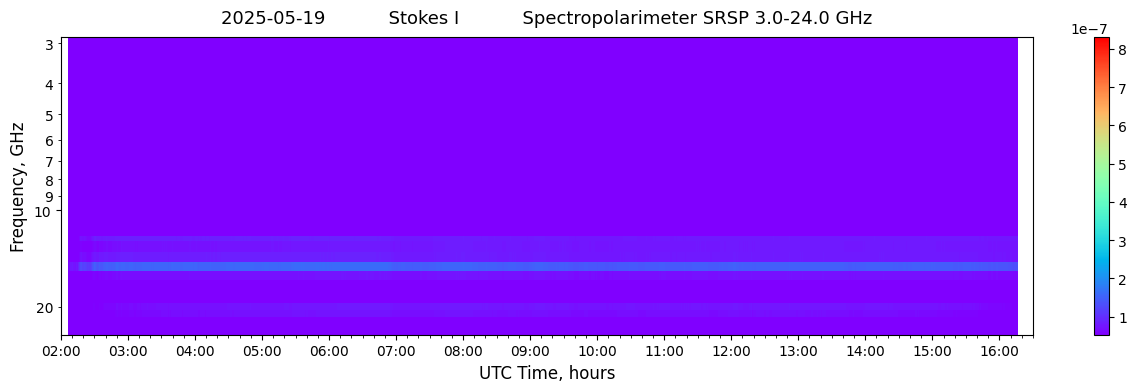

In [17]:
plotSpectra(radiodata, freqrange=[0, 39], pol=0, yscalelog=True,
             vmin=5.3e-8, vmax=8.3e-7, # 3-24 GHz
             dateview=dateviewfits,
             t1 = "02:00", t2 = "16:30",
             # cmap='hot',
             cmap='rainbow',
             # improve= True, 
             # saveplot=True
            )